<a href="https://colab.research.google.com/github/sedefcoskun/EEG-Music-Analysis-ML/blob/main/01_Data_Ingestion_and_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Notebook 01: Data Ingestion & Feature Engineering

This notebook serves as the foundational data engineering pipeline for analyzing multimodal brain activity in response to auditory stimuli. It is strictly designed to handle raw EEG signal acquisition, structural dataset validation, and purely independent feature extraction without target variable contamination.

## Pipeline Architecture
1. **Automated Ingestion:** Securely synchronizes the raw OpenNeuro dataset (ds003774) directly into the cloud workspace via AWS CLI.
2. **BIDS Ecosystem Audit:** Programmatically maps the Brain Imaging Data Structure, isolating hardware metadata (channels.tsv, eeg.json) and targeted .set signal files from legacy unsegmented data.
3. **Signal Processing & Epoching:** Applies rigorous filtering (1-45 Hz bandpass, 50Hz notch) and segments the continuous EEG data into 3.0-second epochs with 50% overlap. This specific 3-second temporal window was strategically chosen to yield a high frequency resolution (~0.33 Hz), ensuring the robust capture of slow-wave Delta oscillations (1-4 Hz) via Welch's Power Spectral Density (PSD) method.
4. **Multimodal Feature Extraction:** Computes absolute, logarithmic, and relative power band features across standard physiological ranges (Delta, Theta, Alpha, Beta, Gamma). The resulting multidimensional feature matrix is exported securely for downstream Machine Learning and Deep Learning model development.

### 1. Workspace Configuration & Environment Setup
To ensure secure and reproducible access to the data, cloud storage (Google Drive) integration has been established, and the primary working directory has been configured.

In [ ]:
import os
from google.colab import drive

# Mount Google Drive to access project workspace
drive.mount('/content/drive')

# Define the path to main project directory
project_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN'
os.makedirs(project_dir, exist_ok=True)

# Set the current working directory
os.chdir(project_dir)
print(f"Working directory successfully set to: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory successfully set to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN


### 2. Dependency Installation & Data Synchronization
Required Python libraries for signal processing (MNE), data manipulation (Pandas, NumPy), and machine learning (Scikit-Learn) are installed. Additionally, the AWS CLI is utilized to securely synchronize the raw EEG data from OpenNeuro directly into the project workspace.

In [ ]:
# Install the necessary libraries for the EEG processing pipeline
!pip install mne pandas numpy scikit-learn awscli

import os

# Define the data directory
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
os.makedirs(raw_bids_dir, exist_ok=True)

print("Initiating raw EEG data synchronization via AWS S3...")

# Utilizing AWS CLI for direct, fail-safe synchronization
!aws s3 sync --no-sign-request s3://openneuro.org/ds003774 {raw_bids_dir}

print("Data synchronization completed successfully.")

Initiating raw EEG data synchronization via AWS S3...
download: s3://openneuro.org/ds003774/CHANGES to ds003774_data/CHANGES                
download: s3://openneuro.org/ds003774/Code/Experiment_NSMusic.es2 to ds003774_data/Code/Experiment_NSMusic.es2
download: s3://openneuro.org/ds003774/Code/ESongs/7.esh.wav to ds003774_data/Code/ESongs/7.esh.wav
download: s3://openneuro.org/ds003774/Code/ESongs/6.esh.wav to ds003774_data/Code/ESongs/6.esh.wav
download: s3://openneuro.org/ds003774/Code/ESongs/4.esh.wav to ds003774_data/Code/ESongs/4.esh.wav
download: s3://openneuro.org/ds003774/Code/ESongs/1.esh.wav to ds003774_data/Code/ESongs/1.esh.wav
download: s3://openneuro.org/ds003774/Code/ESongs/10.esh.wav to ds003774_data/Code/ESongs/10.esh.wav
download: s3://openneuro.org/ds003774/Code/single beep(close)/Sound to close eyes.wav to ds003774_data/Code/single beep(close)/Sound to close eyes.wav
download: s3://openneuro.org/ds003774/Code/ESongs/8.esh.wav to ds003774_data/Code/ESongs/8.esh.wav
d

### 3. Comprehensive BIDS Ecosystem Audit
DATASET EXPLORATION

To ensure full compliance with Brain Imaging Data Structure (BIDS) standards and to validate our extraction strategy, we conduct a transparent architectural audit of the entire dataset.

Rather than merely verifying the root directory, this ecosystem map programmatically isolates our segmented EEG targets (sub-XXX/ses-YY) from the unsegmented raw data (sourcedata) and experiment stimuli. This structural validation explicitly tags the files required for feature extraction while actively bypassing legacy event anomalies, establishing a robust and transparent data pipeline.



In [ ]:
# DATASET EXPLORATION

from pathlib import Path
from typing import Union

def audit_bids_ecosystem(base_path: Union[str, Path]) -> None:
    """
    Conducts a complete, unsparing architectural audit of the MUSIN-G BIDS data.

    This function transparently maps the complete ecosystem hierarchy. It lists ALL
    files within the sample directories to demonstrate full BIDS compliance. It
    explicitly tags the extraction pipeline's target files while clearly marking
    unsegmented continuous data ('sourcedata') as intentionally bypassed.

    Args:
        base_path (Union[str, Path]): The absolute path to the data root directory.
    """
    raw_bids_dir = Path(base_path)

    print("FULL DATA ECOSYSTEM AUDIT")
    print(f"Target Directory: {raw_bids_dir.name}\n")

    if not raw_bids_dir.exists():
        print("[ERROR] Base directory path not found. Please verify the Google Drive mount.")
        return

    # 1. ROOT METADATA
    print("📁 [ROOT METADATA]")
    for f in sorted(raw_bids_dir.glob('*.*')):
        if f.is_file():
            print(f" ├── 📄 {f.name}")

    # 2. CODE & AUDIO STIMULI
    code_dir = raw_bids_dir / "Code"
    if code_dir.exists():
        print("\n📁 Code/ (Experiment Scripts & Audio Assets)")
        for item in sorted(code_dir.iterdir()):
            if item.is_dir() and item.name == 'ESongs':
                songs = sorted(list(item.glob('*.wav')))
                if songs:
                    print(f" ├── 📁 ESongs/")
                    print(f" │    ├── 🎵 {songs[0].name}")
                    print(f" │    └── ... ({len(songs)-1} more audio files)")
            else:
                icon = '📁' if item.is_dir() else '📄'
                print(f" ├── {icon} {item.name}")

    # 3. STIMULI
    stim_dir = raw_bids_dir / "stimuli"
    if stim_dir.exists():
        print("\n📁 stimuli/ (Event Triggers)")
        for item in sorted(stim_dir.iterdir()):
            icon = '📁' if item.is_dir() else '📄'
            print(f" ├── {icon} {item.name}")

    # 4. SOURCEDATA (Raw Unsegmented EEG - Transparently Listed)
    source_dir = raw_bids_dir / "sourcedata"
    if source_dir.exists():
        print("\n📁 sourcedata/ (Continuous/Unsegmented EEG)")
        sample_src = source_dir / "sub-001" / "eeg"
        if sample_src.exists():
            print(f" ├── 📁 sub-001/eeg/")
            source_files = sorted([f for f in sample_src.iterdir() if f.is_file()])

            # Show all files in sourcedata, but explicitly tag them as bypassed
            for f in source_files:
                print(f" │    ├── 📄 {f.name}  <-- [BYPASSED: Unsegmented Raw Data]")

        print(" └── 📁 ... (Remaining subjects follow this bypassed structure)")

    # 5. SEGMENTED BIDS TARGET DATA (TRANSPARENT LISTING)
    print("\n📁 Segmented BIDS Target Data (sub-XXX)")
    target_sub = raw_bids_dir / "sub-001"
    if target_sub.exists():
        print(f" ├── 📁 sub-001/")
        sessions = sorted([d for d in target_sub.iterdir() if d.is_dir() and "ses-" in d.name])

        # Check the first session explicitly to show full structure
        if sessions:
            ses = sessions[0]
            print(f" │    ├── 📁 {ses.name}/eeg/")
            eeg_dir = ses / "eeg"

            if eeg_dir.exists():
                eeg_files = sorted([f for f in eeg_dir.iterdir() if f.is_file()])

                # Show every file, but tag the ones we actually use
                for f in eeg_files:
                    if f.name.endswith('.set'):
                        print(f" │    │    ├── 🧠 {f.name}  <-- [TARGET: Raw Signal]")
                    elif f.name.endswith('channels.tsv') or f.name.endswith('eeg.json'):
                        print(f" │    │    ├── 📄 {f.name}  <-- [TARGET: Metadata]")
                    elif f.name.endswith('events.tsv'):
                        print(f" │    │    ├── 📄 {f.name}  <-- [BYPASSED: Anomaly per README]")
                    else:
                        print(f" │    │    ├── 📄 {f.name}")
            else:
                print(f" │    │    └── [WARNING] 'eeg' subdirectory missing.")

            if len(sessions) > 1:
                print(f" │    ├── 📁 {sessions[1].name}/eeg/ ... (Identical structure)")

        print(f" │    └── 📁 ... (Total {len(sessions)} sessions mapped)")
        print(" └── 📁 ... (sub-002 to sub-020 follow this exact segmented architecture)")

# Execution Block
if __name__ == "__main__":
    RAW_BIDS_DIR = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
    audit_bids_ecosystem(base_path=RAW_BIDS_DIR)

FULL DATA ECOSYSTEM AUDIT
Target Directory: ds003774_data

📁 [ROOT METADATA]
 ├── 📄 .gitattributes
 ├── 📄 dataset_description.json

📁 Code/ (Experiment Scripts & Audio Assets)
 ├── 📁 ESongs/
 │    ├── 🎵 1.esh.wav
 │    └── ... (11 more audio files)
 ├── 📄 Experiment_NSMusic.es2
 ├── 📄 Experiment_NSMusic.es2.c2e496CA
 ├── 📁 double beep(open)
 ├── 📁 single beep(close)

📁 stimuli/ (Event Triggers)
 ├── 📄 Behavioural_data
 ├── 📄 Song_Description
 ├── 📄 song_metadata.csv

📁 sourcedata/ (Continuous/Unsegmented EEG)
 ├── 📁 sub-001/eeg/
 │    ├── 📄 sub-001_task-ListeningandResponse_channels.tsv  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_coordsystem.json  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_eeg.json  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_eeg.set  <-- [BYPASSED: Unsegmented Raw Data]
 │    ├── 📄 sub-001_task-ListeningandResponse_electrodes.tsv  <-- [BYPASSED: Unseg

### 4. EEG Data Structure Overview (Hardware Metadata & Electrode Architecture - channels.tsv)

This section inspects the EEG channel configuration file (channels.tsv) included in the BIDS dataset.

The goal is to understand:
- Channel names and types
- Recording reference structure
- Data quality and consistency across channels

This step ensures that downstream feature extraction is based on correctly interpreted EEG channel metadata.

In [ ]:
import pandas as pd
import json
import glob
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# Display EEG Channel Content
print("EEG CHANNELS DATA (channels.tsv)")

# Find the first channels.tsv file for subject 1
channels_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*channels.tsv'), recursive=True))

if channels_files:
    first_channel_file = channels_files[0]
    print(f"Loading file: {os.path.basename(first_channel_file)}\n")

    # Read and display the raw content
    df_channels = pd.read_csv(first_channel_file, sep='\t')
    print(df_channels.head(15)) # Showing first 15 channels
    print(f"\nTotal Channels in file: {len(df_channels)}")

# Display EEG Metadata Content
print("EEG HARDWARE METADATA (eeg.json) \n")

# Find the first eeg.json file for subject 1
json_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*eeg.json'), recursive=True))

if json_files:
    first_json_file = json_files[0]
    print(f"Loading file: {os.path.basename(first_json_file)}\n")

    # Read the JSON file
    with open(first_json_file, 'r') as f:
        eeg_metadata = json.load(f)

    # Print the raw JSON content in a readable format
    print(json.dumps(eeg_metadata, indent=4))
else:
    print("Files not found. Check directory structure.")

EEG CHANNELS DATA (channels.tsv)
Loading file: sub-001_ses-01_task-MusicListening_run-1_channels.tsv

   name type   units
0    E1  EEG  microV
1    E2  EEG  microV
2    E3  EEG  microV
3    E4  EEG  microV
4    E5  EEG  microV
5    E6  EEG  microV
6    E7  EEG  microV
7    E8  EEG  microV
8    E9  EEG  microV
9   E10  EEG  microV
10  E11  EEG  microV
11  E12  EEG  microV
12  E13  EEG  microV
13  E14  EEG  microV
14  E15  EEG  microV

Total Channels in file: 129
EEG HARDWARE METADATA (eeg.json) 

Loading file: sub-001_ses-01_task-MusicListening_run-1_eeg.json

{
    "PowerLineFrequency": 50,
    "SoftwareFilters": {
        "FilterDescription": {
            "Description": "None"
        }
    },
    "HardwareFilters": {
        "FilterDescription": {
            "Description": "None"
        }
    },
    "SoftwareVersions": "Netstation 5.4",
    "ManufacturersModelName": "NetAmps 400",
    "Manufacturer": "MagstimEG",
    "EEGPlacementScheme": "EGI",
    "EEGGround": "None",
    "EEGR

###5. Electrode Positioning Information (electrodes.tsv)

This section loads electrode spatial coordinates from the BIDS dataset.

The electrode metadata includes:
- 3D spatial positions (X, Y, Z)
- Electrode labeling consistency
- Reference for potential spatial analysis

This step is used for dataset understanding and does not directly affect feature extraction.

In [ ]:
import pandas as pd
import json
import glob
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'

# Display Electrode Posıtıons
print("ELECTRODE 3D POSITIONS (electrodes.tsv)\n")

# Find the first electrodes.tsv file for subject 1
electrodes_files = sorted(glob.glob(os.path.join(raw_bids_dir, 'sub-001', '**', '*electrodes.tsv'), recursive=True))

if electrodes_files:
    first_electrode_file = electrodes_files[0]
    print(f"Loading file: {os.path.basename(first_electrode_file)}\n")

    # Read and display the raw content (X, Y, Z coordinates)
    df_electrodes = pd.read_csv(first_electrode_file, sep='\t')
    print(df_electrodes.head(15)) # Showing first 15 electrode coordinates
    print(f"\nTotal Electrodes listed: {len(df_electrodes)}")
else:
    print("electrodes.tsv file not found.\n")



ELECTRODE 3D POSITIONS (electrodes.tsv)

Loading file: sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv

   name      x     y     z
0    E1   6.30 -6.61 -2.94
1    E2   7.66 -6.04  0.35
2    E3   8.72 -4.41  3.50
3    E4   8.16 -3.28  5.70
4    E5   6.49 -1.69  7.78
5    E6   4.35 -0.00  9.01
6    E7   1.78  1.40  9.64
7    E8   9.13 -4.82 -1.55
8    E9  10.14 -3.08  1.24
9   E10   9.94 -2.09  3.64
10  E11   9.09 -0.00  5.76
11  E12   6.49  1.69  7.78
12  E13   3.71  2.78  8.69
13  E14  10.82 -1.45 -1.08
14  E15  10.37 -0.00  1.52

Total Electrodes listed: 129


###6. Raw EEG Signal Visualization (Quality Check)

This section performs a sanity check on raw EEG recordings by visualizing a short time window of the signal.

The purpose is to verify:
- Signal continuity
- Noise levels
- Sampling rate consistency
- Proper loading of EEGLAB .set files

This is a diagnostic step to ensure data integrity before feature extraction.

RAW EEG SIGNAL VISUALIZATION (Checking)
Inspecting a valid, segmented song session to verify continuous data quality...

Successfully loaded targeted session file: sub-001_ses-01_task-MusicListening_run-1_eeg.set

--- TARGET DATA METADATA ---
Total Channels: 129
Sampling Rate: 250.0 Hz
Recording Length: 136.03 seconds (Expected: ~60-180s for a single song segment)

Rendering signal visualization...


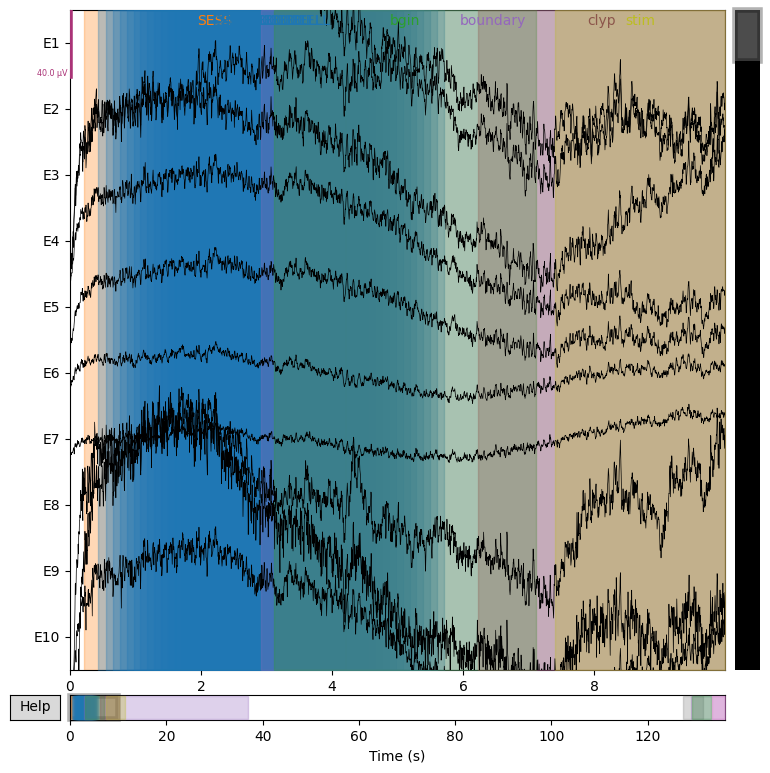

In [ ]:
import mne
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

# Suppress runtime warnings to maintain a clean and professional standard output
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

# Define the base data directory synchronized via AWS
raw_bids_dir = Path('/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data')

print("RAW EEG SIGNAL VISUALIZATION (Checking)")
print("Inspecting a valid, segmented song session to verify continuous data quality...\n")

# Target the segmented session directory (ses-01), strictly avoiding the unsegmented 'sourcedata'
target_session_dir = raw_bids_dir / "sub-001" / "ses-01" / "eeg"

if target_session_dir.exists():
    # Isolate the specific .set file for the target session
    eeg_files = list(target_session_dir.glob("*.set"))

    if eeg_files:
        sample_file = eeg_files[0]
        print(f"Successfully loaded targeted session file: {sample_file.name}")

        try:
            # Load the raw EEG timeseries data into memory using the EEGLAB reader
            raw = mne.io.read_raw_eeglab(sample_file, preload=True)

            # Output hardware and recording metadata for the sanity check report
            print("\n--- TARGET DATA METADATA ---")
            print(f"Total Channels: {raw.info['nchan']}")
            print(f"Sampling Rate: {raw.info['sfreq']} Hz")
            print(f"Recording Length: {raw.times[-1]:.2f} seconds (Expected: ~60-180s for a single song segment)")

            # Render a clean, professional visualization of the first 10 seconds across 10 channels
            print("\nRendering signal visualization...")
            fig = raw.plot(duration=10, n_channels=10, title="Sample Segmented EEG (sub-001, ses-01)", show=False)
            plt.show()

        except Exception as e:
            print(f"[ERROR] Failed to process continuous EEG data: {e}")
    else:
        print("[WARNING] No '.set' files were found in the targeted session directory.")
else:
    print("[ERROR] Target session directory not found. Please verify the structural integrity of the BIDS path.")

###7. Stimuli Dataset Overview

This section lists the contents of the stimuli directory, which contains experimental audio files and related materials.

The purpose is to:
- Verify the presence of stimulus audio files
- Understand experimental inputs used during EEG recording
- Ensure dataset completeness for reproducibility

This information is not directly used in feature extraction but is important for experimental context.

In [ ]:
import os

# Define data path
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
stimuli_dir = os.path.join(raw_bids_dir, 'stimuli')

# List files inside the stimuli folder to see what it contains
if os.path.exists(stimuli_dir):
    print("Content of Stimuli Directory")
    print(os.listdir(stimuli_dir))
else:
    print("Stimuli directory not found.")

Content of Stimuli Directory
['song_metadata.csv', 'Song_Description', 'Behavioural_data']


In [ ]:
import os
import pandas as pd

# Define paths
raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
behavioral_path = os.path.join(raw_bids_dir, 'stimuli', 'Behavioural_data')
custom_metadata_path = os.path.join(raw_bids_dir, 'stimuli', 'song_metadata.csv')

print("EXPERIMENTAL PARADIGM & METADATA PREVIEW")
print("Inspecting behavioral responses and stimulus metadata prior to Machine Learning integration.\n")

try:
    # 1. Load and display Song Metadata
    df_songs_preview = pd.read_csv(custom_metadata_path)
    print("STIMULUS METADATA (Songs)")
    display(df_songs_preview)

    # 2. Load and display Behavioral Responses
    df_behavior_preview = pd.read_csv(behavioral_path, sep=r'\s+')
    df_behavior_preview.columns = df_behavior_preview.columns.str.strip()
    print("\nBEHAVIORAL RESPONSES (Participant Surveys)")
    display(df_behavior_preview)

except Exception as e:
    print(f"Could not load metadata for preview: {e}")

EXPERIMENTAL PARADIGM & METADATA PREVIEW
Inspecting behavioral responses and stimulus metadata prior to Machine Learning integration.

STIMULUS METADATA (Songs)


,Song_ID,Track_Name,Genre,Duration(sec),Tempo(BPM),Vocal_Language
0,1,Trip to the lonely planet - Mark Alow,Deep House,125,121.95,Instrumental
1,2,Sail - Awolnation,Indie,114,119.00,English
2,3,Concept 15 - Kodomo,Electronics,132,161.00,Instrumental
3,4,Aurore - Claire David,New Age,111,NaN,Instrumental
4,5,Proof - Idiotape,Electronic Dance,124,123.00,Instrumental
5,6,Glider - Tycho,Ambient,100,126.00,Instrumental
6,7,Raag Bihag - B.Sivaramakrishna Rao,Hindustani Classical,116,70.00,Instrumental
7,8,Albela sajan - Ismail Darbar,Indian Semi-Classical,121,194.00,Hindi
8,9,Mor Bani Thanghat Kare - Sanjay Leela Bhansali,Indian Folk,126,117.00,Gujarati
9,10,Fallin - Dr. SaxLove,Soft Jazz,129,197.00,Instrumental



BEHAVIORAL RESPONSES (Participant Surveys)


,Subject,Song_ID,Enjoyment,Familiarity
0,1,1,2,2
1,1,2,3,2
2,1,3,3,3
3,1,4,2,2
4,1,5,2,2
...,...,...,...,...
235,20,8,2,3
236,20,9,2,5
237,20,10,1,4
238,20,11,1,5


### 8. Methodological Justification (Epoch Window Optimization)

In this project, we set the time windows (epochs) to 3 seconds when processing the EEG signals. The main reason for this was to ensure we didn't miss the slow Delta waves (1-4 Hz) that emerge while listening to music. In signal processing, as the window duration decreases, frequency resolution drops. If we had used 1 or 2-second windows, we wouldn't have been able to capture the full cycle of a slow 1 Hz wave, resulting in distortions known as spectral leakage. A 3-second window provided us with a highly effective resolution of approximately 0.33 Hz, allowing us to capture even the slowest waves. Furthermore, we applied a 50% overlap to prevent any data loss at the boundaries of the windows.



Simulating Spectral Resolution Constraints for Delta Band (1 Hz)



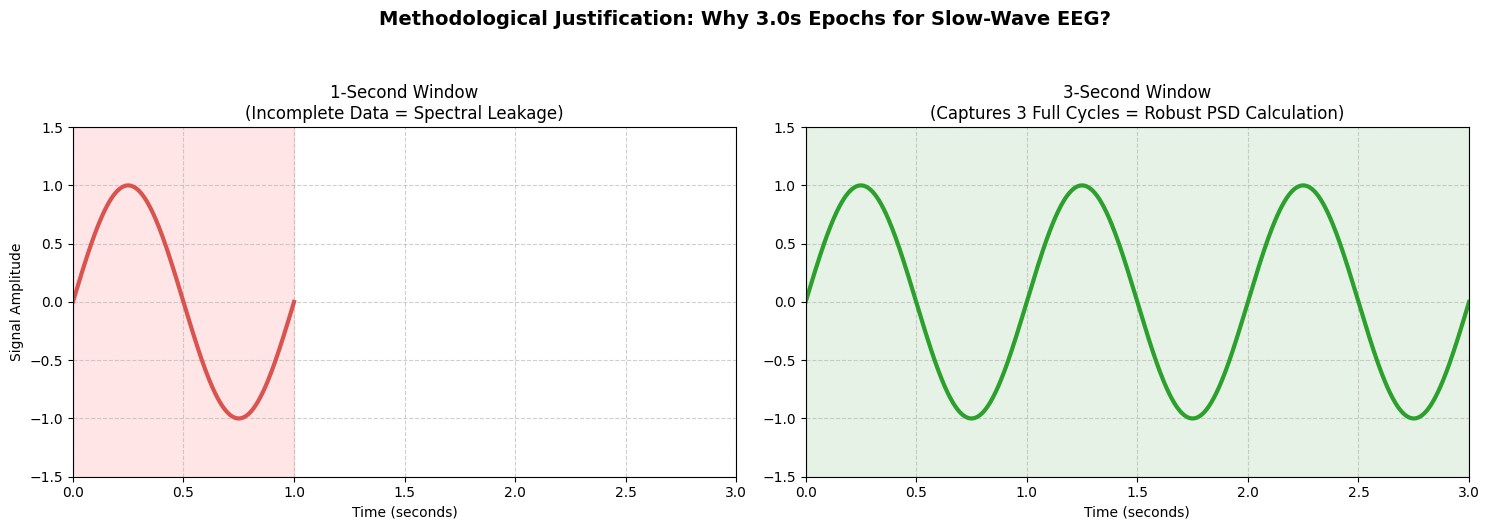

Visual proof successfully generated and saved to: /content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/epoch_justification.png
Proceeding to Step 9: Feature Extraction Pipeline with optimized 3.0s windows.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Simulating Spectral Resolution Constraints for Delta Band (1 Hz)\n")

# Simulate a 1 Hz Delta wave over 3 seconds
t = np.linspace(0, 3, 1000)
delta_wave = np.sin(2 * np.pi * 1 * t)

# Create a professional 1x2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Methodological Justification: Why 3.0s Epochs for Slow-Wave EEG?', fontsize=14, fontweight='bold', y=1.05)

# Subplot 1: The Flawed 1-Second Window
axes[0].plot(t[t<=1], delta_wave[t<=1], color='#d9534f', lw=3)
axes[0].set_title('1-Second Window\n(Incomplete Data = Spectral Leakage)', fontsize=12)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Signal Amplitude')
axes[0].set_xlim(0, 3)
axes[0].set_ylim(-1.5, 1.5)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].axvspan(0, 1, color='red', alpha=0.1)

# Subplot 2: The Optimal 3-Second Window
axes[1].plot(t, delta_wave, color='#2ca02c', lw=3)
axes[1].set_title('3-Second Window\n(Captures 3 Full Cycles = Robust PSD Calculation)', fontsize=12)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_xlim(0, 3)
axes[1].set_ylim(-1.5, 1.5)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].axvspan(0, 3, color='green', alpha=0.1)

justification_fig_path = f'{project_dir}/epoch_justification.png'
plt.tight_layout()
plt.savefig(justification_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Visual proof successfully generated and saved to: {justification_fig_path}")
print("Proceeding to Step 9: Feature Extraction Pipeline with optimized 3.0s windows.")

### 9. Pure Feature Engineering (Leakage-Resistant)

This module represents the core data engineering phase. Continuous EEG signals are segmented into 3.0s fixed-length epochs with 50% overlap to ensure temporal stability, particularly for low-frequency bands (Delta).

Spectral features are extracted using Welch's method for Power Spectral Density (PSD).

Note: To strictly prevent data leakage and maintain a publication-grade separation of concerns, this pipeline only constructs the independent variable matrix (X). Target labels and behavioral metadata (y) are intentionally excluded and will be merged only during the Machine Learning preprocessing phase.

In [ ]:
import os
import glob
import mne
import numpy as np
import pandas as pd
from mne.time_frequency import psd_array_welch
import warnings

# Global Settings
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

print("EEG FEATURE EXTRACTION PIPELINE")
print("Advanced Filtering, Epoching & Multimodal Features\n")

raw_bids_dir = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/ds003774_data'
output_path = '/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/01_raw_dataset.csv'

# Frequency Bands
freq_bands = {
    'Delta': (1, 4), 'Theta': (4, 8), 'Alpha': (8, 13),
    'Beta':  (13, 30), 'Gamma': (30, 45)
}

all_features = []
epoch_counter = 0
total_subjects = 20
total_songs = 12

for sub_num in range(1, total_subjects + 1):
    sub_id = f"sub-{sub_num:03d}"
    print(f"Processing {sub_id}...")

    for song_id in range(1, total_songs + 1):
        ses_id = f"ses-{song_id:02d}"
        search_pattern = os.path.join(raw_bids_dir, sub_id, ses_id, 'eeg', '*.set')
        eeg_files = glob.glob(search_pattern)

        if not eeg_files:
            continue

        try:
            # 1. Load & Filter
            raw = mne.io.read_raw_eeglab(eeg_files[0], preload=True, verbose=False)
            raw.filter(l_freq=1.0, h_freq=45.0, verbose=False) # Removes noise
            raw.notch_filter(freqs=50, verbose=False)
            sfreq = raw.info['sfreq']

            # 2. Epoching (Correct overlap: 1.5 seconds for 3.0s duration)
            epochs = mne.make_fixed_length_epochs(
                raw, duration=3.0, overlap=1.5, preload=True, verbose=False
            )
            epochs_data = epochs.get_data()
        except Exception:
            continue

        # 3. PSD Extraction
        for ep_data in epochs_data:
            try:
                psds, freqs = psd_array_welch(ep_data, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, verbose=False)

                row = {
                    "epoch_id": epoch_counter,
                    "Subject": sub_num,
                    "Song_ID": song_id,
                    "Group_ID": (sub_num * 100) + song_id
                }

                total_mask = (freqs >= 1) & (freqs <= 45)

                for ch_idx, ch_name in enumerate(raw.info['ch_names']):
                    total_power = np.nansum(psds[ch_idx, total_mask]) + 1e-12

                    for band, (fmin, fmax) in freq_bands.items():
                        mask = (freqs >= fmin) & (freqs <= fmax)
                        band_power = np.nanmean(psds[ch_idx, mask]) if np.any(mask) else 0

                        # Advanced Features
                        row[f"{ch_name}_{band}_abs"] = band_power
                        row[f"{ch_name}_{band}_log"] = np.log10(band_power + 1e-12)
                        row[f"{ch_name}_{band}_rel"] = band_power / total_power

                all_features.append(row)
                epoch_counter += 1
            except Exception:
                continue

        del raw

# 4. Final Compilation & Normalization
df_extracted = pd.DataFrame(all_features)
print(f"\nExtraction completed. Raw Shape: {df_extracted.shape}")

df_extracted.to_csv(output_path, index=False)
print(f"Saved optimized dataset to: {output_path}")


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/ML_Project_2026_SEDEF_COŞKUN/01_raw_dataset.csv')

print("DATASET INTEGRITY CHECK")
print("Shape:", df.shape)

if df.shape[0] >= 5000:
    print("5000+ Epoch Requirement PASSED.")
else:
    print("WARNING: Dataset lacks 5000 rows.")

print("\nTotal Missing Values (NaN):", df.isna().sum().sum())

feature_cols = [c for c in df.columns if any(suffix in c for suffix in ["_abs", "_log", "_rel"])]
print(f"\nNumber of valid EEG features extracted: {len(feature_cols)}")

print("\nUNIQUE IDENTIFIERS")
print(f"Subjects: {df['Subject'].nunique()} | Songs: {df['Song_ID'].nunique()} | Groups: {df['Group_ID'].nunique()}")
print("Ready for Machine Learning Pipeline (Notebook 02).")

print("\nFeature Type Counts")

abs_count = len([c for c in feature_cols if "_abs" in c])
log_count = len([c for c in feature_cols if "_log" in c])
rel_count = len([c for c in feature_cols if "_rel" in c])

print(f"Absolute Power Features : {abs_count}")
print(f"Log Power Features      : {log_count}")
print(f"Relative Power Features : {rel_count}")

DATASET INTEGRITY CHECK
Shape: (20382, 1939)
5000+ Epoch Requirement PASSED.

Total Missing Values (NaN): 0

Number of valid EEG features extracted: 1935

UNIQUE IDENTIFIERS
Subjects: 20 | Songs: 12 | Groups: 240
Ready for Machine Learning Pipeline (Notebook 02).

Feature Type Counts
Absolute Power Features : 645
Log Power Features      : 645
Relative Power Features : 645


In [ ]:
print("\nFINAL DATASET PREVIEW (NOTEBOOK 01 OUTPUT)")
print("Note: This matrix contains ONLY independent EEG features.")
print("Behavioral targets and labels will be safely integrated in Notebook 02.\n")

display(df.head())


FINAL DATASET PREVIEW (NOTEBOOK 01 OUTPUT)
Note: This matrix contains ONLY independent EEG features.
Behavioral targets and labels will be safely integrated in Notebook 02.



,epoch_id,Subject,Song_ID,Group_ID,E1_Delta_abs,E1_Delta_log,E1_Delta_rel,E1_Theta_abs,E1_Theta_log,E1_Theta_rel,...,E129_Theta_rel,E129_Alpha_abs,E129_Alpha_log,E129_Alpha_rel,E129_Beta_abs,E129_Beta_log,E129_Beta_rel,E129_Gamma_abs,E129_Gamma_log,E129_Gamma_rel
0,0,1,1,101,4.833034e-12,-11.234105,0.092740,4.149766e-12,-11.288213,0.079629,...,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0
1,1,1,1,101,4.649021e-12,-11.248027,0.093751,7.851620e-13,-11.748322,0.015833,...,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0
2,2,1,1,101,5.445238e-12,-11.190761,0.101614,1.748000e-12,-11.560983,0.032620,...,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0
3,3,1,1,101,4.983786e-12,-11.223024,0.137780,6.251822e-13,-11.789098,0.017284,...,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0
4,4,1,1,101,8.649708e-12,-11.015486,0.178021,6.688021e-13,-11.777595,0.013765,...,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0,0.0,-12.0,0.0
